In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import Perceptron, LogisticRegression, SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, PowerTransformer

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_LIMPOS
from src.graficos import plot_coeficientes, plot_comparar_metricas_modelos
from src.models import RANDOM_STATE
from src.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,...,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
1,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,...,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
2,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,...,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
3,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,...,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
4,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,...,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


In [3]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [4]:
le = LabelEncoder()

y = le.fit_transform(y)

y[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [5]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [6]:
preprocessamento = Pipeline(
    steps=[("scaler", PowerTransformer())]
)

In [7]:
classificadores = {
    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified")
    },

    "Perceptron": {
        "preprocessor": preprocessamento,
        "classificador": Perceptron()
    },

    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression()
    },

    "SGDClassifier": {
        "preprocessor": preprocessamento,
        "classificador": SGDClassifier()
    },
    
}

In [9]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados.head(10)

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.002694,0.017199,0.429825,0.413855,0.315789,0.288462,0.348837,0.540616,0.399513,0.019893
1,DummyClassifier,0.001732,0.01963,0.491228,0.444808,0.275,0.297297,0.255814,0.573043,0.42041,0.021362
2,DummyClassifier,0.001532,0.012402,0.517544,0.489087,0.367816,0.355556,0.380952,0.526786,0.381955,0.013934
3,DummyClassifier,0.00142,0.012573,0.517544,0.489087,0.367816,0.355556,0.380952,0.451389,0.349318,0.013993
4,DummyClassifier,0.001142,0.008807,0.557522,0.502012,0.324324,0.375,0.285714,0.408283,0.340467,0.009949
5,Perceptron,0.044306,0.011748,0.947368,0.953161,0.933333,0.893617,0.976744,0.992139,0.98945,0.056054
6,Perceptron,0.042476,0.011491,0.964912,0.96266,0.953488,0.953488,0.953488,0.99869,0.997909,0.053967
7,Perceptron,0.042688,0.011784,0.947368,0.943452,0.928571,0.928571,0.928571,0.982474,0.977233,0.054472
8,Perceptron,0.039736,0.012012,0.973684,0.979167,0.965517,0.933333,1.0,1.0,1.0,0.051747
9,Perceptron,0.042648,0.011626,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.054273


In [10]:
df_resultados.groupby("model").mean().sort_values("test_recall")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.001704,0.014122,0.502732,0.46777,0.330149,0.334374,0.330454,0.500023,0.378332,0.015826
LogisticRegression,0.142419,0.020769,0.975408,0.970873,0.96636,0.981258,0.952935,0.996632,0.995721,0.163189
SGDClassifier,0.052164,0.014184,0.966636,0.964751,0.955191,0.954376,0.957475,0.994723,0.992611,0.066348
Perceptron,0.042371,0.011732,0.966667,0.967688,0.956182,0.941802,0.971761,0.99466,0.992919,0.054103


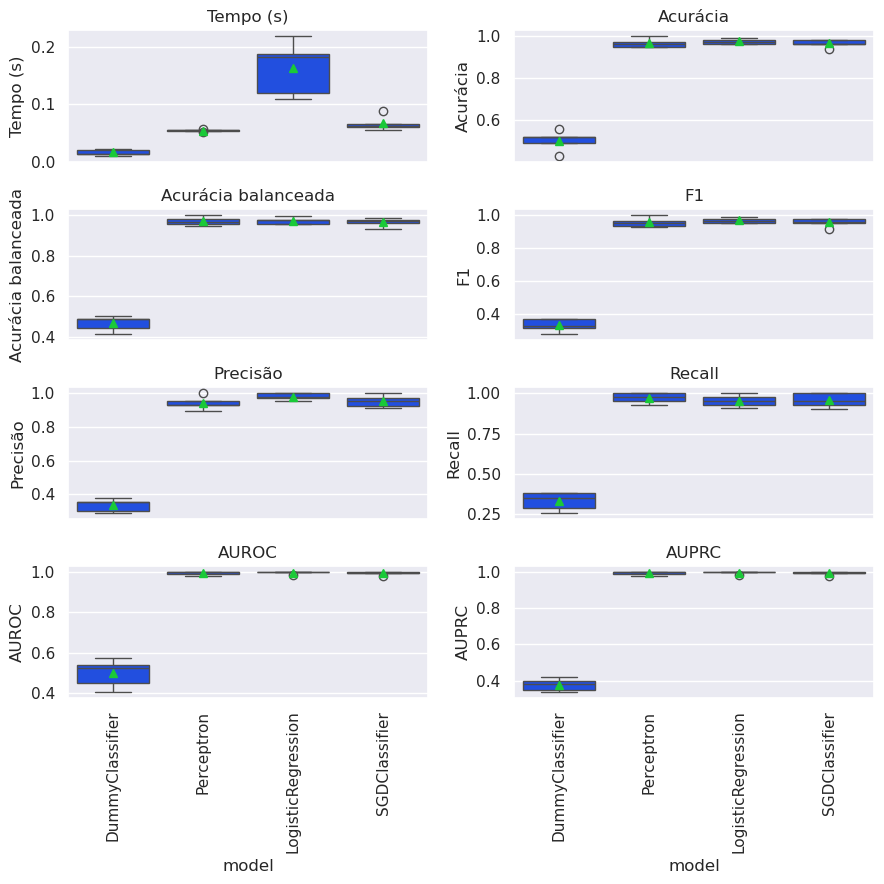

In [11]:
plot_comparar_metricas_modelos(df_resultados)

In [15]:
param_grid = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2", "elasticnet", None],
    "clf__class_weight": [None, "balanced"]
}

In [16]:
clf = LogisticRegression(solver="saga", random_state=RANDOM_STATE)

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, preprocessamento, refit_metric="recall"
)

grid_search

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        Pipeline(steps=[('scaler',
                                                         PowerTransformer())])),
                                       ('clf',
                                        LogisticRegression(random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__class_weight': [None, 'balanced'],
                         'clf__penalty': ['l1', 'l2', 'elasticnet', None]},
             refit='recall',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [17]:
grid_search.fit(X, y)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


/home/hilario/anaconda3/envs/MachineLearning/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hilario/anaconda3/envs/MachineLearning/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hilario/anaconda3/envs/MachineLearning/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/hilario/anaconda3/envs/MachineLearning/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hilario/anaconda3/envs/MachineLearning/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C 

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        Pipeline(steps=[('scaler',
                                                         PowerTransformer())])),
                                       ('clf',
                                        LogisticRegression(random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__class_weight': [None, 'balanced'],
                         'clf__penalty': ['l1', 'l2', 'elasticnet', None]},
             refit='recall',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)